<a href="https://colab.research.google.com/github/5star55/EDA-Exercise/blob/main/OutlierTreatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import statistics
import matplotlib as plt
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Learning-data-analytics/raw_sales2.csv')

In [ ]:
data.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3
5,2007-04-04 00:00:00,2905,465000,house,4
6,2007-04-24 00:00:00,2607,399000,house,3
7,2007-04-30 00:00:00,2606,1530000,house,4
8,2007-05-24 00:00:00,2902,359000,house,3
9,2007-05-25 00:00:00,2906,320000,house,3


In [18]:
def anomalies_detector(Data):
  anomalies=[]

  mean=statistics.mean(Data)
  std=statistics.stdev(Data)
  cutoff=mean*3

  lower_cutoff=mean-cutoff
  upper_cutoff=mean+cutoff

  for data in Data:
    if data>upper_cutoff or data<lower_cutoff:
      anomalies.append(data);
  return anomalies;

In [31]:
outliers=anomalies_detector(data['price'])

In [29]:
data['price'].mean()


np.float64(609736.262204192)

In [30]:
data['price'].std()

281707.9053741625

In [34]:
len(outliers)

52

In [35]:
outliers

[3500000,
 2600000,
 7300000,
 4150000,
 2500000,
 5425000,
 2760000,
 2600000,
 3160000,
 3400000,
 2550000,
 3400000,
 2450000,
 2660000,
 8000000,
 2440000,
 2585000,
 3950000,
 2595000,
 3625000,
 6480000,
 5475000,
 2520000,
 4417000,
 2470000,
 3000000,
 2475000,
 2570000,
 2485000,
 3500000,
 4220000,
 2900000,
 2875000,
 2950000,
 4700000,
 3160000,
 2500000,
 2970000,
 2925000,
 3050000,
 2600000,
 2800000,
 3750000,
 2900000,
 2740000,
 2950000,
 2701000,
 2500000,
 2610000,
 2575000,
 4500000,
 2500000]

In [36]:
data.price.skew()

np.float64(4.312009366902366)

In [37]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Density'>

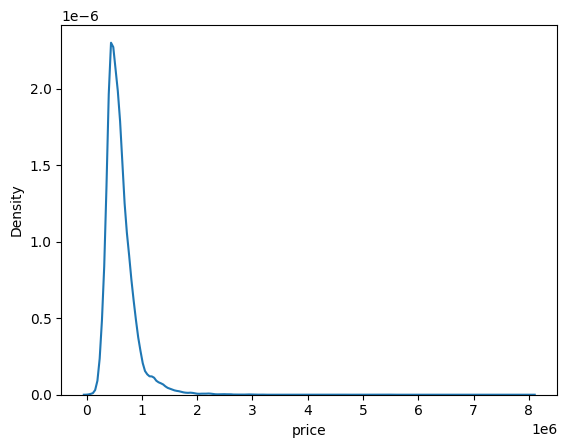

In [38]:
sns.kdeplot(data.price)

In [40]:
data['price_transformed']=np.log(data['price'])

In [42]:
data['price_transformed'].skew()

np.float64(0.4731646269984763)

<Axes: xlabel='price_transformed', ylabel='Density'>

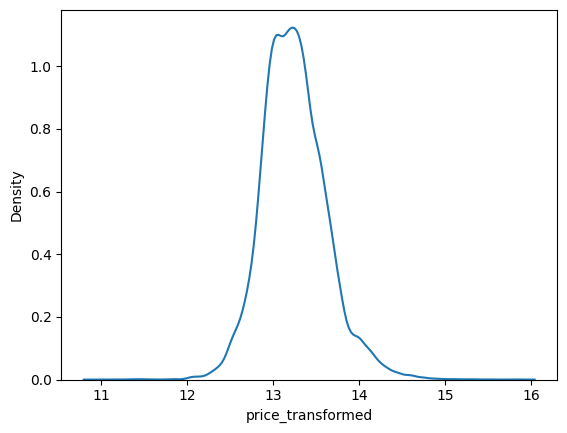

In [44]:
sns.kdeplot(data['price_transformed'])

In [45]:
anomalies=anomalies_detector(data['price_transformed'])

In [46]:
len(anomalies)

0

#Using boxplots

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

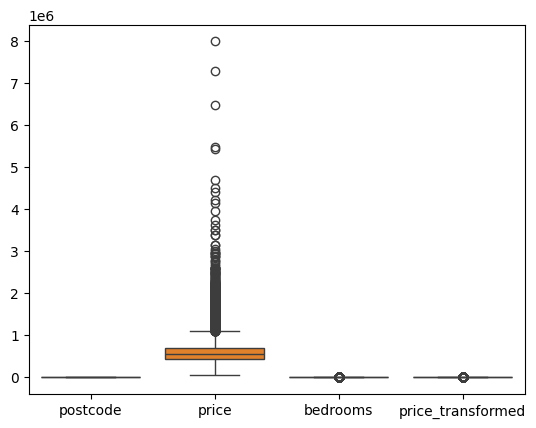

In [49]:
sns.boxplot(data)

<Axes: ylabel='price'>

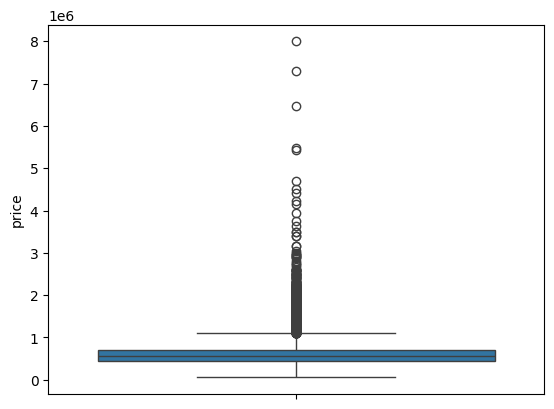

In [50]:
sns.boxplot(data['price'])

In [53]:
df=pd.DataFrame(data)

In [55]:
wdf.head(10)

,datesold,postcode,price,propertyType,bedrooms,price_transformed
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328
5,2007-04-04 00:00:00,2905,465000,house,4,13.049793
6,2007-04-24 00:00:00,2607,399000,house,3,12.896717
7,2007-04-30 00:00:00,2606,1530000,house,4,14.240778
8,2007-05-24 00:00:00,2902,359000,house,3,12.791078
9,2007-05-25 00:00:00,2906,320000,house,3,12.676076


In [56]:
df.describe()

,postcode,price,bedrooms,price_transformed
count,29580.000000,2.958000e+04,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695
std,146.717292,2.817079e+05,0.951275,0.375214
min,2600.000000,5.650000e+04,0.000000,10.941996
25%,2607.000000,4.400000e+05,3.000000,12.994530
50%,2615.000000,5.500000e+05,3.000000,13.217674
75%,2905.000000,7.050000e+05,4.000000,13.465953
max,2914.000000,8.000000e+06,5.000000,15.894952


#Getting Percentiles

In [58]:
data['price'].quantile(0.5) #50th percentile

np.float64(550000.0)

In [59]:
data['price'].quantile(0.75)

np.float64(705000.0)